#Content based recommendation system using movies genres

estimated complile time 2 hrs add code to save and delete matrix 1 before model 2 is complied

import requirements

In [1]:
!pip install fuzzywuzzy
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
from genericpath import isfile
import zipfile
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from fuzzywuzzy import process
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import joblib
from sklearn.decomposition import PCA


/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


automated downloading of the 33 million movielens dataset

In [2]:
try:
  if os.path.isfile("/content/movielen.zip")==False:
      filename = "movielen.zip"
      url ="https://files.grouplens.org/datasets/movielens/ml-latest.zip"
      with requests.get(url, stream=True) as r:
          r.raise_for_status()
          with open(filename, 'wb') as f:
              for chunk in r.iter_content(chunk_size=8192):
                  f.write(chunk)
      print("movies completed")
  else:
    print("movie dataset already exist")
except Exception as e:
    print("\n the following error occured with downloading the movies file: ",e)

movies completed


data extraction of downloaded file such unzipping

In [3]:
with zipfile.ZipFile("movielen.zip","r") as zip_ref:
  zip_ref.extractall()
  print("Extracted files:")
  for file in zip_ref.namelist():
        print(file)

Extracted files:
ml-latest/
ml-latest/tags.csv
ml-latest/links.csv
ml-latest/README.txt
ml-latest/ratings.csv
ml-latest/genome-tags.csv
ml-latest/genome-scores.csv
ml-latest/movies.csv


reading in of data from the movies and ratings csv files

In [4]:
try:
  movies =pl.read_csv("/content/ml-latest/movies.csv")
  print("sucessfully read movies csv")

  ratings =pl.read_csv("/content/ml-latest/ratings.csv")
  print("sucessfully read ratings csv")
except Exception as e:
  print("the following error occurred : ", e)


sucessfully read movies csv
sucessfully read ratings csv


In [5]:
print(movies)
print(ratings)

shape: (86_537, 3)
┌─────────┬─────────────────────────────────┬─────────────────────────────────┐
│ movieId ┆ title                           ┆ genres                          │
│ ---     ┆ ---                             ┆ ---                             │
│ i64     ┆ str                             ┆ str                             │
╞═════════╪═════════════════════════════════╪═════════════════════════════════╡
│ 1       ┆ Toy Story (1995)                ┆ Adventure|Animation|Children|C… │
│ 2       ┆ Jumanji (1995)                  ┆ Adventure|Children|Fantasy      │
│ 3       ┆ Grumpier Old Men (1995)         ┆ Comedy|Romance                  │
│ 4       ┆ Waiting to Exhale (1995)        ┆ Comedy|Drama|Romance            │
│ 5       ┆ Father of the Bride Part II (1… ┆ Comedy                          │
│ …       ┆ …                               ┆ …                               │
│ 288967  ┆ State of Siege: Temple Attack … ┆ Action|Drama                    │
│ 288971  ┆ Ouija Jap

column validation for both movies and rating dataset

In [6]:
required_columns_movies =['movieId','title','genres']
data_col_movies =movies.columns
required_columns_ratings =['userId','movieId','rating','timestamp']
data_col_ratings =ratings.columns

if required_columns_movies == data_col_movies:
  print(f"all movies features are present")
  print(f' {required_columns_movies}')
else:
  missing_col_movies = [ x  for x in data_col_movies if x not in required_columns_movies]
  print(f"  the foling features are missing: {missing_col_movies}")
if required_columns_ratings == data_col_ratings:
  print(f"all ratings  features are present")
  print(f'  {required_columns_ratings}')
else:
  missing_col_rating = [ x  for x in data_col_ratings if x not in required_columns_ratings]
  print(f"  the foling required features are missing: {missing_col_rating}")


all movies features are present
 ['movieId', 'title', 'genres']
all ratings  features are present
  ['userId', 'movieId', 'rating', 'timestamp']


due to hardware consrtrainst the full dataset could not be computed in colab so a sample of 1 million was taken from the rating


In [7]:
ratings.sample(n=100000,with_replacement=False,shuffle =True,seed=42)

userId,movieId,rating,timestamp
i64,i64,f64,i64
268821,4993,4.0,1447221027
106201,31410,4.5,1166264023
325721,150,5.0,839313246
230978,149406,4.0,1473433160
262070,2944,3.0,1202403788
…,…,…,…
55000,96417,4.0,1378053326
89580,1090,5.0,998942506
329018,213245,2.5,1582539564


#data exploration

from the dataset rating over time

/tmp/ipykernel_2329/565351488.py:10: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


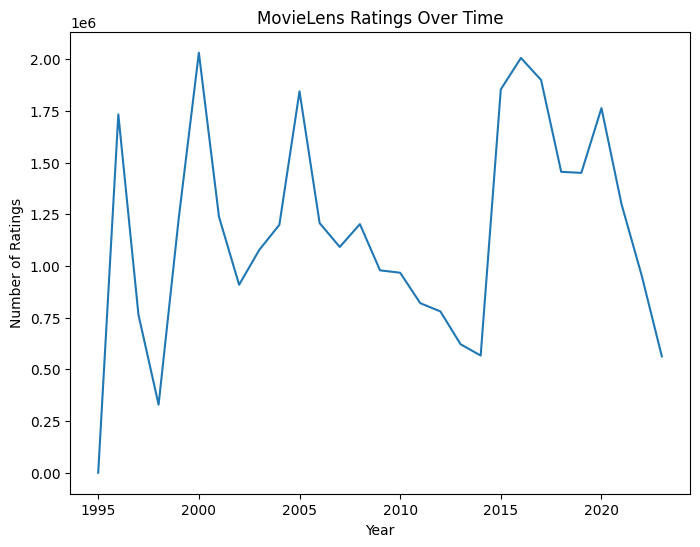

In [8]:
ratings = ratings.with_columns(
    pl.from_epoch("timestamp", time_unit="s").alias("datetime")
).with_columns(
    pl.col("datetime").dt.year().alias("year")
)

ratings_per_year = (
    ratings
    .group_by("year")
    .count()
    .sort("year")
)

plt.figure(figsize=(8, 6))
plt.plot(ratings_per_year["year"], ratings_per_year["count"])
plt.title("MovieLens Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()

distribution of ratings

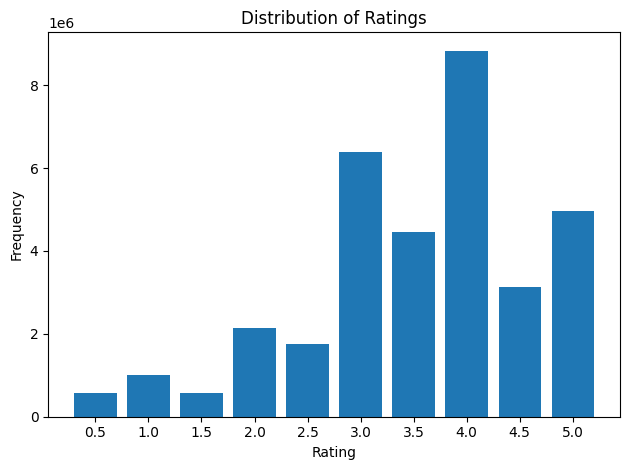

In [9]:
rating_counts = (
    ratings
    .group_by("rating")
    .len()
    .sort("rating")
)

plt.figure()
plt.bar(rating_counts["rating"], rating_counts["len"], width=0.4)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.xticks(rating_counts["rating"])
plt.tight_layout()
plt.show()

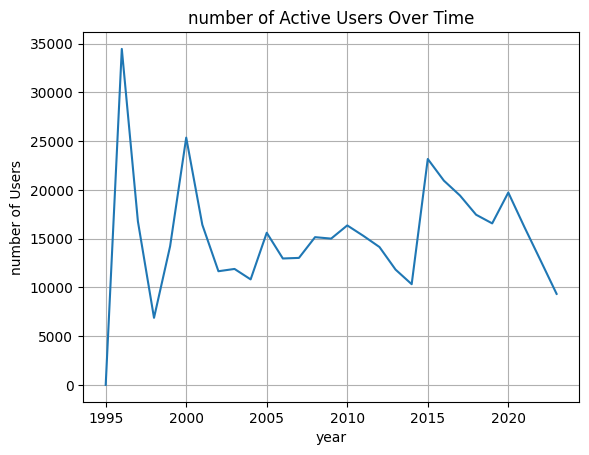

In [10]:
ratings = ratings.with_columns(
    pl.from_epoch("timestamp", time_unit="s").alias("datetime")
).with_columns(
    pl.col("datetime").dt.year().alias("year")
)

users_per_year = (
    ratings
    .group_by("year")
    .agg(pl.col("userId").n_unique().alias("num_users"))
    .sort("year")
)

plt.figure()
plt.plot(users_per_year["year"], users_per_year["num_users"])
plt.title("number of Active Users Over Time")
plt.xlabel("year")
plt.ylabel("number of Users")
plt.grid()
plt.show()

In [11]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].n_unique()
n_users = ratings['userId'].n_unique()

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 33832162
Number of unique movieId's: 83239
Number of unique users: 330975
Average number of ratings per user: 102.22
Average number of ratings per movie: 406.45


from the distribution the dataset is left skewed, with the mode rating being 4.0. overall the dataset is skewed to the positive with high the rating being positive. this can indicate that there is a small amount of negatively reviewed movies or that users tend to be more positive or generous when rating but can be influenced since users who like something tend to do the extra effort of rating aposed to disliking where they ignore it.

In [12]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")
mean_ratings = ratings.group_by("userId").agg(pl.col("rating").mean().alias("mean_rating"))
print(f"Mean rating per user: {round(mean_ratings.select(pl.col('mean_rating').mean()).item(),2)}.")

Mean global rating: 3.54.
Mean rating per user: 3.7.


from the chat above we can see the 10 most rated movies..since the ratings and movies were seperate so merging was needed, to get the total ratings per movie

In [13]:
mean_ratings =ratings.group_by('movieId').agg(pl.col('rating').mean().alias("mean_rate_per_movie"))
min_mean =mean_ratings.select(pl.col("mean_rate_per_movie").min()).item()

lowest_rated_movies =mean_ratings.filter(pl.col("mean_rate_per_movie") ==min_mean)

lowest_rated_movies_with_titles = lowest_rated_movies.join(movies, on="movieId")
print(lowest_rated_movies_with_titles)


shape: (1_229, 4)
┌─────────┬─────────────────────┬──────────────────────────┬─────────────────────────────────┐
│ movieId ┆ mean_rate_per_movie ┆ title                    ┆ genres                          │
│ ---     ┆ ---                 ┆ ---                      ┆ ---                             │
│ i64     ┆ f64                 ┆ str                      ┆ str                             │
╞═════════╪═════════════════════╪══════════════════════════╪═════════════════════════════════╡
│ 5805    ┆ 0.5                 ┆ Besotted (2001)          ┆ Drama                           │
│ 80781   ┆ 0.5                 ┆ Vampitheatre (2009)      ┆ Horror                          │
│ 85694   ┆ 0.5                 ┆ Diamond Girl (1998)      ┆ Drama|Romance                   │
│ 87962   ┆ 0.5                 ┆ Dreamkiller (2010)       ┆ Thriller                        │
│ 93083   ┆ 0.5                 ┆ Live Music (2009)        ┆ Animation                       │
│ …       ┆ …                   

the movie besotted has the lowest rating in the dataset

In [14]:
max_mean = mean_ratings.select(pl.col("mean_rate_per_movie").max()).item()

highest_rated_movies = mean_ratings.filter(pl.col("mean_rate_per_movie") == max_mean).head(1)

highest_rated_movies_with_titles = highest_rated_movies.join(movies, on="movieId")
print(highest_rated_movies_with_titles)

shape: (1, 4)
┌─────────┬─────────────────────┬────────────────┬────────────────────┐
│ movieId ┆ mean_rate_per_movie ┆ title          ┆ genres             │
│ ---     ┆ ---                 ┆ ---            ┆ ---                │
│ i64     ┆ f64                 ┆ str            ┆ str                │
╞═════════╪═════════════════════╪════════════════╪════════════════════╡
│ 192229  ┆ 5.0                 ┆ Ctrl+Alt+Dance ┆ (no genres listed) │
└─────────┴─────────────────────┴────────────────┴────────────────────┘


from the dataset the most rated movie is Always a Bridesmaid, but is subjected to change as an 5.0 movie

In [15]:
movie_id = highest_rated_movies_with_titles['movieId'].item()

num_users = ratings.filter(pl.col('movieId') == movie_id).height
print(f"Number of users who rated movie {movie_id}: {num_users}")

Number of users who rated movie 192229: 1


while viewing the rating of the highest rated movie,we can see that while it had a 5.0 rating, it was only rated by one user.

#data preprocessing

In [16]:
movies = movies.with_columns(pl.col('genres').str.split("|"))

print(movies.head())

shape: (5, 3)
┌─────────┬─────────────────────────────────┬─────────────────────────────────┐
│ movieId ┆ title                           ┆ genres                          │
│ ---     ┆ ---                             ┆ ---                             │
│ i64     ┆ str                             ┆ list[str]                       │
╞═════════╪═════════════════════════════════╪═════════════════════════════════╡
│ 1       ┆ Toy Story (1995)                ┆ ["Adventure", "Animation", … "… │
│ 2       ┆ Jumanji (1995)                  ┆ ["Adventure", "Children", "Fan… │
│ 3       ┆ Grumpier Old Men (1995)         ┆ ["Comedy", "Romance"]           │
│ 4       ┆ Waiting to Exhale (1995)        ┆ ["Comedy", "Drama", "Romance"]  │
│ 5       ┆ Father of the Bride Part II (1… ┆ ["Comedy"]                      │
└─────────┴─────────────────────────────────┴─────────────────────────────────┘


the genres for each movie were seperated allowing for easy processing

In [17]:
genre_frequency = Counter(g for genres in movies['genres'] for g in genres)
print(f"There are {len(genre_frequency)} genres.")
genre_frequency

There are 20 genres.


Counter({'Adventure': 5349,
         'Animation': 4579,
         'Children': 4367,
         'Comedy': 22830,
         'Fantasy': 3821,
         'Romance': 10172,
         'Drama': 33681,
         'Action': 9563,
         'Crime': 6917,
         'Thriller': 11675,
         'Horror': 8570,
         'Mystery': 3972,
         'Sci-Fi': 4850,
         'IMAX': 195,
         'Documentary': 9283,
         'War': 2301,
         'Musical': 1059,
         'Western': 1690,
         'Film-Noir': 354,
         '(no genres listed)': 7060})

In [18]:
print("The 5 most common genres: \n", genre_frequency.most_common(5))

The 5 most common genres: 
 [('Drama', 33681), ('Comedy', 22830), ('Thriller', 11675), ('Romance', 10172), ('Action', 9563)]


In [19]:
genres = movies['genres'].explode().unique().to_list()

movie_genres =movies.with_columns([pl.col('genres').list.contains(g).cast(pl.Int8).alias(g)for g in genres])
movie_genres =movie_genres.drop(['movieId','title','genres'])

print(movie_genres.head())

shape: (5, 20)
┌───────┬─────────┬──────┬──────────┬───┬───────────┬─────────┬────────┬────────────────────┐
│ Drama ┆ Romance ┆ IMAX ┆ Thriller ┆ … ┆ Adventure ┆ Musical ┆ Action ┆ (no genres listed) │
│ ---   ┆ ---     ┆ ---  ┆ ---      ┆   ┆ ---       ┆ ---     ┆ ---    ┆ ---                │
│ i8    ┆ i8      ┆ i8   ┆ i8       ┆   ┆ i8        ┆ i8      ┆ i8     ┆ i8                 │
╞═══════╪═════════╪══════╪══════════╪═══╪═══════════╪═════════╪════════╪════════════════════╡
│ 0     ┆ 0       ┆ 0    ┆ 0        ┆ … ┆ 1         ┆ 0       ┆ 0      ┆ 0                  │
│ 0     ┆ 0       ┆ 0    ┆ 0        ┆ … ┆ 1         ┆ 0       ┆ 0      ┆ 0                  │
│ 0     ┆ 1       ┆ 0    ┆ 0        ┆ … ┆ 0         ┆ 0       ┆ 0      ┆ 0                  │
│ 1     ┆ 1       ┆ 0    ┆ 0        ┆ … ┆ 0         ┆ 0       ┆ 0      ┆ 0                  │
│ 0     ┆ 0       ┆ 0    ┆ 0        ┆ … ┆ 0         ┆ 0       ┆ 0      ┆ 0                  │
└───────┴─────────┴──────┴──────────┴───┴────

In [20]:
movie_genres.head()

Drama,Romance,IMAX,Thriller,Fantasy,Western,War,Animation,Crime,Children,Film-Noir,Horror,Documentary,Mystery,Comedy,Sci-Fi,Adventure,Musical,Action,(no genres listed)
i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0
0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


#Model 1 hot one encoding movie genre with cosine similarty matix

In [21]:
pca =PCA(n_components=0.95)

movie_genres_pca= pca.fit_transform(movie_genres)

print(f'Original features: {movie_genres.shape[1]}')
print(f'PCA features (95% variance): {movie_genres_pca.shape[1]}')
print(f'Reduction: {1 - movie_genres_pca.shape[1]/movie_genres.shape[1]:.0%} fewer features')

Original features: 20
PCA features (95% variance): 15
Reduction: 25% fewer features


In [22]:
def batched_cosine_to_disk(X, block_size=4000, filepath="cosine_matrix.dat"):
    n =X.shape[0]

    S =np.memmap(filepath, dtype='float32', mode='w+', shape=(n, n))

    for i in range(0,n,block_size):
        i_end =min(i + block_size, n)
        Xi =X[i:i_end]

        for j in range(i,n, block_size):
            j_end = min(j +block_size, n)
            Xj = X[j:j_end]

            block =cosine_similarity(Xi,Xj)

            S[i:i_end, j:j_end] =block
            S[j:j_end,i:i_end] = block.T
    S.flush()
    return filepath

The solution to this problem was batched matrix calculation, this is where sections of the matrix are calculated separately and the substituted into the a blank full size matrix ,with the full matrix being stored on disk and the needed section of the matrix that needs to be populated would be read and populated as needed. Thai batched matrix works by calculating the cosine similarity to the first section or block,proceeding to calculate the cosine similarity of block1 to each other block, this is repeated for every other block. The process for this is as follows : a matrix of size 87 000 was created and populated with only zeros(blank matrix).Using the numpy function, memap which allows the needed sections of the matrix to be read into memory as numpy array  as needed without the whole file. The parameters for this function are the filename,the expected datatype set to int64, mode, the operation to be performed on the file, set to w+, allowing overwriting of the file with new block. The outer FOR loop iterates by starting from 0 and selecting blocks of the specified block size till it reaches the last block ‘n’. Inside this loop, the end of the block i  is then calculated, preventing a block that exceeds the matrix size from being used. Then that block is stored as a variable, the second FOR loop is used to get the other preceding blocks for cosine calculation, with the same exceeding block prevention handling, the cosine similarity of the block i to itself is calculated followed by the calculation of all other proceeding blocks. After each cosine block is calculated, it is read into the blank matrix, storing it as rows from block i and the columns from block j. Due to cosine similarity being symmetrical, instead of recalculating block j to block i, we transpose the cosine block and write that into the blank matrix where rows from block j and columns from block i. After this process is repeated and completed, memap has a feature called flush which commits all changes made to the array to the stored file.


In [23]:
cosine_sim =  batched_cosine_to_disk(movie_genres)

To retrieve recommendation from the completed cosine matrix, two helper functions are needed, movie finder function, using a library called fuzzy wuzzy which helps find movies even if the user input is not the exact match. The function works by creating a list of all the titles from the movies dataframe and then using fuzzy wuzzy function process.extractOne is compares the input to all titles and creates a list to of the movies in order of closest match, then returns the closest match


In [28]:
def get_movie_similarities(movie_idx, filepath, n):
    S =np.memmap(filepath, dtype="float32", mode="r", shape=(n, n))
    row =S[movie_idx]
    return row

The second helper function get movie similarities works by reading the stored cosine matrix and selecting the row that matches the input movie index.

In [29]:
def movie_finder(title):
    all_titles = movies['title'].to_list()
    closest_match = process.extractOne(title,all_titles)
    return closest_match[0]

These two movies are combined to create a function that get the recommendation called get content based recommendation, this functions works by  firstly retrieving the exact movie title by is of the movie finder function and is then used to create a map of each movie to their numeric index and the selected movie index is then extracted. The row of that movie is the selected with use of the the get movie similarities function, this row is copied and the similarity of the selected movie is the set to -1 to prevent re-recommending it, the row is then used with numpy argpartition that get the highest similarity movies with -row used because argpartition normally get the minimum scores.these array is the sorted and the movies names than index match the index in the movies dataframe.


In [30]:
def get_content_based_recommendations(title_string, n_recommendations=10, filepath="cosine_matrix.dat"):
    title = movie_finder(title_string)
    movie_idx =  dict(zip(
    movies["title"].to_list(),
    range(len(movies))
))
    idx = movie_idx[title]

    n = len(movie_idx)
    row = get_movie_similarities(idx, filepath, n).copy()

    row[idx] = -1

    top_idx = np.argpartition(-row, n_recommendations)[:n_recommendations]
    top_idx = top_idx[np.argsort(-row[top_idx])]

    print(f"Because you watched {title}:")
    print(movies['title'].gather(top_idx))

In [31]:
get_content_based_recommendations('toy story ', 10)

Because you watched Toy Story (1995):
shape: (10,)
Series: 'title' [str]
[
	"My Father's Dragon (2022)"
	"Hotel Transylvania: Transforma…
	"Riverdance: The Animated Adven…
	"Mavka: The Forest Song (2023)"
	"Frozen II (2019)"
	"Moana (2016)"
	"My Little Pony: A New Generati…
	"Penguin Highway (2018)"
	"Chickenhare and the Hamster of…
	"Luca (2021)"
]


#Model 2 term frequency - inverse document frequency with linear kernel

 This was done with regular expression and in a new column called combined. Term frequency - inverse document frequency use two components : term frequency -  how often a word appears in a document and  inverse document frequency this reduces the weight of common words across multiple documents while increasing the weight of rare words. This means that commons may have less meaning than compared a word used less across the documents

the data processing for this method was needed as the genre for  a movie was stored as a list and this needed to be split and quotes removed.

In [32]:
movies = movies.with_columns(
    pl.col("genres")
    .list.eval(
        pl.element().str.replace_all(r'[^\w\s]', '')
    )
    .list.join(" ")
    .alias("combined")
)
print(movies.head())

shape: (5, 4)
┌─────────┬─────────────────────────────┬─────────────────────────────┬────────────────────────────┐
│ movieId ┆ title                       ┆ genres                      ┆ combined                   │
│ ---     ┆ ---                         ┆ ---                         ┆ ---                        │
│ i64     ┆ str                         ┆ list[str]                   ┆ str                        │
╞═════════╪═════════════════════════════╪═════════════════════════════╪════════════════════════════╡
│ 1       ┆ Toy Story (1995)            ┆ ["Adventure", "Animation",  ┆ Adventure Animation        │
│         ┆                             ┆ … "…                        ┆ Children C…                │
│ 2       ┆ Jumanji (1995)              ┆ ["Adventure", "Children",   ┆ Adventure Children Fantasy │
│         ┆                             ┆ "Fan…                       ┆                            │
│ 3       ┆ Grumpier Old Men (1995)     ┆ ["Comedy", "Romance"]       ┆ Comed

Using sklearn tfidfvectorized function creates a matrix of the tf-idf features. A batched matrix was used to calculate the tfidf matrix using the linear kernel. This follows the same procedure as the previous batch matrix prediction but the linear kernel is not symmetric so each block needs to be calculated.


In [33]:
vect = TfidfVectorizer()
matrixt = vect.fit_transform(movies["combined"])
print(matrixt)

def batched_tfidf_to_disk(matrixt, block_size=1000, filepath="tfidf_cosine.dat"):
    n =matrixt.shape[0]

    S =np.memmap(filepath, dtype="float32", mode="w+", shape=(n, n))

    for i in range(0,n,block_size):
        i_end =min(i + block_size, n)
        Xi = matrixt[i:i_end]

        for j in range(0,n,block_size):
            j_end =min(j + block_size, n)
            Xj = matrixt[j:j_end]
            block = linear_kernel(Xi, Xj)
            S[i:i_end, j:j_end] = block
    S.flush()
    return filepath



<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 166408 stored elements and shape (86537, 22)>
  Coords	Values
  (0, 1)	0.45836640775135606
  (0, 2)	0.4771926972142354
  (0, 3)	0.4829344129951208
  (0, 4)	0.2825761772524315
  (0, 8)	0.49911163357006744
  (1, 1)	0.5508360907976553
  (1, 3)	0.5803603834559268
  (1, 8)	0.599801155708829
  (2, 4)	0.5962027850878918
  (2, 17)	0.8028338801105999
  (3, 4)	0.5339395419498466
  (3, 17)	0.718991532629084
  (3, 7)	0.4449266698570324
  (4, 4)	1.0
  (5, 0)	0.5687177003300403
  (5, 5)	0.6262325953285514
  (5, 19)	0.5332850212404032
  (6, 4)	0.5962027850878918
  (6, 17)	0.8028338801105999
  (7, 1)	0.688416814448715
  (7, 3)	0.7253153035641007
  (8, 0)	1.0
  (9, 1)	0.6528148029846615
  (9, 0)	0.552582845770817
  (9, 19)	0.5181554125587448
  :	:
  (86520, 17)	0.8028338801105999
  (86521, 4)	0.5339395419498466
  (86521, 17)	0.718991532629084
  (86521, 7)	0.4449266698570324
  (86522, 11)	1.0
  (86523, 1)	1.0
  (86524, 4)	0.5339395419498466
 

In [34]:
cos_sim= batched_tfidf_to_disk(matrixt)

the same procedure for the cosine similarity recommender was repeated

In [35]:
def get_content_based_recommendationst(title_string, n_recommendations=10, filepath="tfidf_cosine.dat"):
    title = movie_finder(title_string)
    movie_idx = dict(zip(
    movies["title"].to_list(),
    range(len(movies))
))
    idx = movie_idx[title]

    n = len(movie_idx)
    row = get_movie_similarities(idx, filepath, n).copy()
    row[idx] = -1
    top_idx = np.argpartition(-row, n_recommendations)[:n_recommendations]
    top_idx = top_idx[np.argsort(-row[top_idx])]

    print(f"Because you watched {title}:")
    print(movies.select("title").to_series().gather(top_idx))

comparing recommentdation from both cosine similarity and tfidf models

In [36]:
get_content_based_recommendationst("toy story")
get_content_based_recommendations("toy story")

Because you watched Toy Story (1995):
shape: (10,)
Series: 'title' [str]
[
	"Shrek the Third (2007)"
	"Dragons: Dawn Of The Dragon Ra…
	"Turbo (2013)"
	"Emperor's New Groove, The (200…
	"The Good Dinosaur (2015)"
	"Adventures of Rocky and Bullwi…
	"Pil's Adventures (2021)"
	"Bunyan and Babe (2017)"
	"Scooby-Doo! Mask of the Blue F…
	"Tangled: Before Ever After (20…
]
Because you watched Toy Story (1995):
shape: (10,)
Series: 'title' [str]
[
	"My Father's Dragon (2022)"
	"Hotel Transylvania: Transforma…
	"Riverdance: The Animated Adven…
	"Mavka: The Forest Song (2023)"
	"Frozen II (2019)"
	"Moana (2016)"
	"My Little Pony: A New Generati…
	"Penguin Highway (2018)"
	"Chickenhare and the Hamster of…
	"Luca (2021)"
]


#temporal testing

For model evaluation, temporal testing was used, the ratings dataset was selected and sorted according to the timestamp in ascending order. Then a 80 20 train test split was done, the respective dataset were then both grouped by userid in a new column, seen movies for training set and test movies for test set.


In [37]:
rating_sort= ratings.sort("timestamp",descending=False)
split_idx= int(len(rating_sort) * 0.8)
train= rating_sort.with_row_index()[:split_idx]
test= rating_sort.with_row_index()[split_idx:]

train_user = (
    train.filter(pl.col("rating") >=3)
    .group_by("userId")
    .agg(pl.col("movieId").alias("seen_movies")))

test_user= (
    test.filter(pl.col("rating") >= 3)
    .group_by("userId")
    .agg(pl.col("movieId").alias("test_movies")))

print("training data : ",train.shape," testing data :",test.shape)

print("training  u data : ",train_user.shape," testing u data :",test_user.shape)

training data :  (27065729, 7)  testing data : (6766433, 7)
training  u data :  (278787, 2)  testing u data : (58379, 2)


The evaluation metrics used were

precision at k which is the number of relevant item(matches from the user history) divided by all items(k). The function uses an intersection method to see the number of matches in the recommendation and the test set which is divided by k

Recall at k is another metric used, this is the number of relevant movies divided by the total number of relevant items. The function recall at k uses an intersection between recommendation and test datasets and divides the number of matches by the number of values in the test set

Normalised discounted cumulative gain is a ranking metric which uses two metrics: the item position as higher ranked items are more relevant compared to lower ranked ones. The second metric is relevance as higher relevance items should be high on the list. Ndcg is calculated by finding the cumulative gain of the items on the list, then the discounted cumulative gain is calculated by summing each items relevance over a discounting factor. After the ideal discounting cumulative gain, and the ndcg is the discounted cumulative gain divided by ideal cumulative gain


In [38]:
def precision_at_k(recommended, test, k=10):
    recommended_k = recommended[:k]
    if k == 0:
        return 0.0
    return len(set(recommended_k) & set(test)) / k


def recall_at_k(recommended, test, k=10):
    if len(test) == 0:
        return 0.0
    recommended_k = recommended[:k]
    return len(set(recommended_k) & set(test)) / len(test)


def ndcg_at_k(recommended, test, k=10):
    recommended_k = recommended[:k]
    test_set = set(test)

    dcg = 0.0
    for i, item in enumerate(recommended_k):
        if item in test_set:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = min(len(test), k)
    if ideal_hits == 0:
        return 0.0

    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg

def evaluate_recommender(matrix,train_user,test_user, k=10):
    movie_ids = movies["movieId"].to_list()
    id_to_idx = {mid: i for i, mid in enumerate(movie_ids)}
    idx_to_id = {i: row['movieId'] for i, row in enumerate(movies.to_dicts())}

    matrix = np.asarray(matrix)
    max_valid_idx = len(idx_to_id)
    eval_df = train_user.join(test_user, on="userId", how="inner")

    precision_list = []
    recall_list = []
    ndcg_list = []

    for row in eval_df.iter_rows(named=True):

        train_movies = row["seen_movies"]
        test_movies = row["test_movies"]

        if len(train_movies) == 0 or len(test_movies) == 0:
            continue

        train_indices = [id_to_idx[m] for m in train_movies if m in id_to_idx]
        if len(train_indices) == 0:
            continue

        user_scores = matrix[train_indices].mean(axis=0)


        user_scores[train_indices] = -np.inf


        top_indices = np.argsort(-user_scores)[:k]
        recommended_movies = [idx_to_id[i] for i in top_indices]


        precision_list.append(precision_at_k(recommended_movies, test_movies, k))
        recall_list.append(recall_at_k(recommended_movies, test_movies, k))
        ndcg_list.append(ndcg_at_k(recommended_movies, test_movies, k))

    return (
        np.mean(precision_list),
        np.mean(recall_list),
        np.mean(ndcg_list)
    )

the matrix for each model was read back in for temporal testing

In [39]:
cosine_sim = np.memmap(
    "cosine_matrix.dat",
    dtype="float32",
    mode="r"
)
n = int(np.sqrt(len(cosine_sim)))
cosine_sim = cosine_sim.reshape(n, n)

cos_sim = np.memmap(
    "tfidf_cosine.dat",
    dtype="float32",
    mode="r"
)
n = int(np.sqrt(len(cos_sim)))
cos_sim = cos_sim.reshape(n, n)
n_movies_sync = movies.height
cosine_sim_fixed = cosine_sim[:n_movies_sync, :n_movies_sync]
cos_sim_fixed = cos_sim[:n_movies_sync, :n_movies_sync]


In [40]:
pca_prec,pca_rec,pca_ndcg = evaluate_recommender(
    cosine_sim_fixed,
    train_user,
    test_user,
    k=30
)
print(f"PCA Results - Precision: {pca_prec:.4f}, Recall: {pca_rec:.4f}, NDCG: {pca_ndcg:.4f}")

tfidf_prec,tfidf_rec,tfidf_ndcg =evaluate_recommender(
    cos_sim_fixed,
    train_user,
    test_user,
    k=30
)
print(f"TF-IDF Results - Precision: {tfidf_prec:.4f}, Recall: {tfidf_rec:.4f}, NDCG: {tfidf_ndcg:.4f}")

PCA Results - Precision: 0.0068, Recall: 0.0027, NDCG: 0.0071
TF-IDF Results - Precision: 0.0078, Recall: 0.0030, NDCG: 0.0079


from pca results we see that a precision of 0.0068, a recall of 0.0027 and a ndcg of 0.0071, comparing those to the tfidf which got a precision of 0.0078, a recall of 0.0030 and a ndcg of 0.0079, meaning that the tfidf got more relevant movies recommended over all 30 movies recommender compared to the pca and more relevant movies over all relavent movies compared to pca model in terms of recall. in the ndcg, the tfidf also ranked more relevant movies higher compared to pca. overall the tfidf out performed the pca hot one encoding model in every metric making more subtible for recommendations.

also note a reduction from float64 to float32 was done to allow both models matrix to be stored in the 107gb of disk space but unintensionally increased in preformance, from low 4dp figures such as 0.0002 to up 3dp figures but due to lack of time, this reason was not able to be identified. inital theory is matrix density.


model evaluation was preformed with different values of k

In [ ]:
k_list = [1, 5, 10, 15, 20]

pca_results = {'p': [], 'r': [], 'n': []}
tfidf_results = {'p': [], 'r': [], 'n': []}

for k_val in k_list:

    p, r, n = evaluate_recommender(cosine_sim, train_user, test_user, k=k_val)
    pca_results['p'].append(p)
    pca_results['r'].append(r)
    pca_results['n'].append(n)


    p_t, r_t, n_t = evaluate_recommender(cos_sim, train_user, test_user, k=k_val)
    tfidf_results['p'].append(p_t)
    tfidf_results['r'].append(r_t)
    tfidf_results['n'].append(n_t)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


ax1.plot(k_list, pca_results['p'], label='PCA',color='blue')
ax1.plot(k_list, tfidf_results['p'], label='TF-IDF', marker='s', color='orange')
ax1.set_title('Precision @ k (Quality)')
ax1.set_xlabel('k')
ax1.set_ylabel('Precision')
ax1.legend()
ax1.grid(True)

ax2.plot(k_list, pca_results['r'], label='PCA', color='blue')
ax2.plot(k_list, tfidf_results['r'], label='TF-IDF', marker='s', color='orange')
ax2.set_title('Recall @ k (Coverage)')
ax2.set_xlabel('k')
ax2.set_ylabel('Recall')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

from the precision at k graph, at k = 1 , both model had the same value of  0.00025, but at k =5 the tfidf begain out preforming the pca model with 0.0003 compared to pca value of 0.0001, the pca model had drop in preformace but begain to increase in preformance, at k =10 , pca scored 0.00017 but the tfidf scores 0.0003 again. at k = 15 we see that tfidf preformance dropped again to a value of 0.00026, while the pca increased to 0.00019, it still failed to out perform the tfidf model. at the last value k = 20, the pca scored 0.00021 and the tfidf scored 0.00024. overall as the value of k increased above 10 the tfidf preformance degraded but the opposite occured for the pca as k increased, it performace increase except for k = 5, but with increase it still failed to outpreform the tfidf.

for the recall at k, at k =1, both model performed the same with value of 0.0 , but at k= 5, the tfidf got a value of 0.0003 and the pca got a value of 0.0001, at k = 10, the tfidf got a value of 0.0006 and the pca model got a score of 0.0002. at k = 15, the tfidf scored 0.00065 and the pca scored 0.00038. at k = 20, the pca scored 0.0008 and the tfidf scored 0.00085. the general trend of the both models recall at k increasing as k increased but the tfidf model consistently outpreformed the pca model

ai disclosure

the batch matrix prediction method as discovered very late in the timeline of the project and due to tha lack of pratical information on the topic and time restaint , chatgpt was used for explaination which were confirmed by google searches but the code was completed with assitance and the temporal testing, the basic understanding was made and serveral part were completed, however due to lack of time for trouble shooting and lack of working with matrixs cpt was also used to complete it.